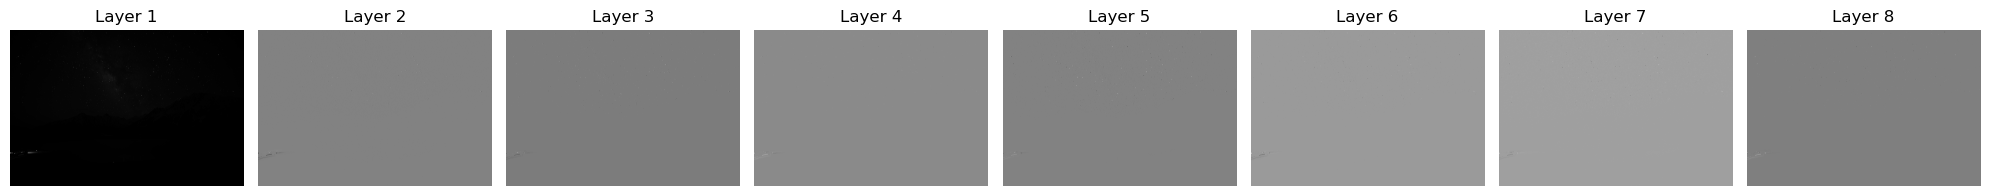

In [5]:
import numpy as np
from PIL import Image
from pathlib import Path
from scipy.linalg import hadamard
import matplotlib.pyplot as plt

# --- Load parameters ---
folder = Path(r"C:\Users\adity\Desktop\DMD\raw")
num_masks = 8

# --- Load and convert images ---
image_paths = sorted(folder.glob("*.tiff"))[:num_masks]
loaded_images = [np.array(Image.open(p).convert("L")) for p in image_paths]
data_cube = np.stack(loaded_images, axis=-1)

# --- Hadamard inverse ---
py, px, m = data_cube.shape
flattened = data_cube.reshape((py * px, m))
H = hadamard(m) / np.sqrt(m)
transformed = np.dot(flattened, H.T)
reconstructed_cube = transformed.reshape((py, px, m))
rearranged_cube = np.swapaxes(reconstructed_cube, 1, 2).transpose(1, 0, 2)  # (m, py, px)

# --- Display 8 layers in a single row ---
plt.figure(figsize=(20, 3))
for i in range(num_masks):
    plt.subplot(1, num_masks, i + 1)
    plt.imshow(rearranged_cube[i], cmap='gray')
    plt.title(f"Layer {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()


 No 3000x1000 feature found. Falling back to center crop.


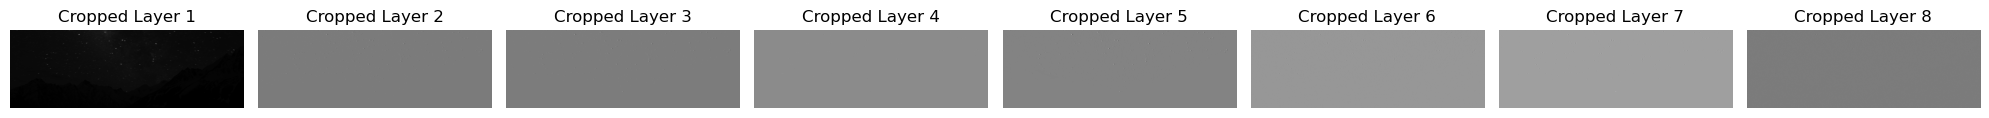

In [7]:
import numpy as np
from PIL import Image
from pathlib import Path
from scipy.linalg import hadamard
import matplotlib.pyplot as plt
import cv2

# --- Setup ---
folder = Path(r"C:\Users\adity\Desktop\DMD\raw")
num_masks = 8
target_width, target_height = 3000, 1000
feature_found = False
tolerance = 0.15  # 15% tolerance in size match

# --- Load and convert to grayscale ---
image_paths = sorted(folder.glob("*.tiff"))[:num_masks]
loaded_images = [np.array(Image.open(p).convert("L")) for p in image_paths]
data_cube = np.stack(loaded_images, axis=-1)

# --- Hadamard inverse ---
py, px, m = data_cube.shape
flattened = data_cube.reshape((py * px, m))
H = hadamard(m) / np.sqrt(m)
transformed = np.dot(flattened, H.T)
reconstructed_cube = transformed.reshape((py, px, m))
rearranged_cube = np.swapaxes(reconstructed_cube, 1, 2).transpose(1, 0, 2)  # (m, py, px)

# --- Search for a ~3000x1000 feature in any layer ---
for i in range(num_masks):
    img = rearranged_cube[i].astype(np.uint8)
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if (
            abs(w - target_width) / target_width < tolerance and
            abs(h - target_height) / target_height < tolerance
        ):
            print(f"Found feature in layer {i+1} at ({x}, {y}) with size ({w}x{h})")
            cropped_cube = rearranged_cube[:, y:y+h, x:x+w]
            feature_found = True
            break
    if feature_found:
        break

# --- Fallback: Center crop if no match ---
if not feature_found:
    print(f" No 3000x1000 feature found. Falling back to center crop.")
    cx, cy = px // 2, py // 2
    half_w, half_h = target_width // 2, target_height // 2
    cropped_cube = rearranged_cube[:, cy - half_h:cy + half_h, cx - half_w:cx + half_w]

# --- Display cropped layers ---
plt.figure(figsize=(20, 3))
for i in range(num_masks):
    plt.subplot(1, num_masks, i + 1)
    plt.imshow(cropped_cube[i], cmap='gray')
    plt.title(f"Cropped Layer {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()


Enter x coordinate (0 to 2999):  68
Enter y coordinate (0 to 999):  69


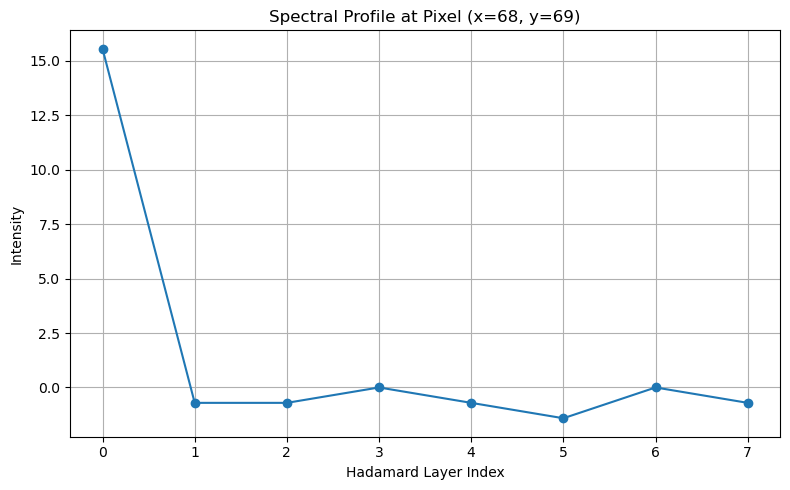

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Input pixel coordinates (x, y) ---
x_coord = int(input("Enter x coordinate (0 to 2999): "))
y_coord = int(input("Enter y coordinate (0 to 999): "))

# --- Get dimensions from cropped_cube ---
m, py, px = cropped_cube.shape  # (8, 1000, 3000)

# --- Check bounds ---
if x_coord >= px or y_coord >= py:
    raise ValueError(f"Coordinates ({x_coord}, {y_coord}) exceed image size ({px}, {py})")

# --- Extract and plot spectral profile (Z direction = Hadamard layers) ---
spectrum = cropped_cube[:, y_coord, x_coord]

plt.figure(figsize=(8, 5))
plt.plot(np.arange(m), spectrum, marker='o')
plt.title(f"Spectral Profile at Pixel (x={x_coord}, y={y_coord})")
plt.xlabel("Hadamard Layer Index")
plt.ylabel("Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
#import librart
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [10]:
cube=fits.open(r"C:\Users\adity\Downloads\manga-7443-12703-LOGCUBE\manga-7443-12703-LOGCUBE.fits")
cube.info()

Filename: C:\Users\adity\Downloads\manga-7443-12703-LOGCUBE\manga-7443-12703-LOGCUBE.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      75   ()      
  1  FLUX          1 ImageHDU       100   (74, 74, 4563)   float32   
  2  IVAR          1 ImageHDU        17   (74, 74, 4563)   float32   
  3  MASK          1 ImageHDU        17   (74, 74, 4563)   int32   
  4  LSFPOST       1 ImageHDU        11   (74, 74, 4563)   float32   
  5  LSFPRE        1 ImageHDU        11   (74, 74, 4563)   float32   
  6  WAVE          1 ImageHDU         9   (4563,)   float64   
  7  SPECRES       1 ImageHDU         9   (4563,)   float64   
  8  SPECRESD      1 ImageHDU         9   (4563,)   float64   
  9  PRESPECRES    1 ImageHDU         9   (4563,)   float64   
 10  PRESPECRESD    1 ImageHDU         9   (4563,)   float64   
 11  OBSINFO       1 BinTableHDU    148   15R x 65C   [25A, 17A, 5A, J, I, 9A, E, E, E, E, E, E, J, J, I, J, E, 12A, J, 8A, E, E, E, 

In [11]:
#read HDU
flux= cube[1].data
#header
cube[1].header


XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                   74 /                                                
NAXIS2  =                   74 /                                                
NAXIS3  =                 4563 /                                                
PCOUNT  =                    0 / No Group Parameters                            
GCOUNT  =                    1 / One Data Group                                 
AUTHOR  = 'Brian Cherinka & David Law <bcherinka@stsci.edu, dlaw@stsci.edu>' /  
VERSDRP2= 'v3_1_1  '           / MaNGA DRP version (2d processing)              
VERSDRP3= 'v3_1_1  '           / MaNGA DRP Version (3d processing)              
VERSPLDS= 'v5_1    '           / Platedesign Version                            
VERSFLAT= 'v1_33   '        

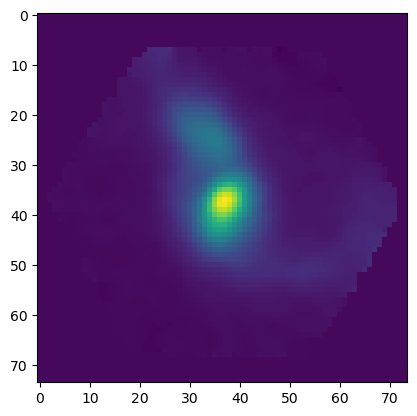

In [12]:
image= flux[2000,:,:] #3000A
plt.imshow(image)

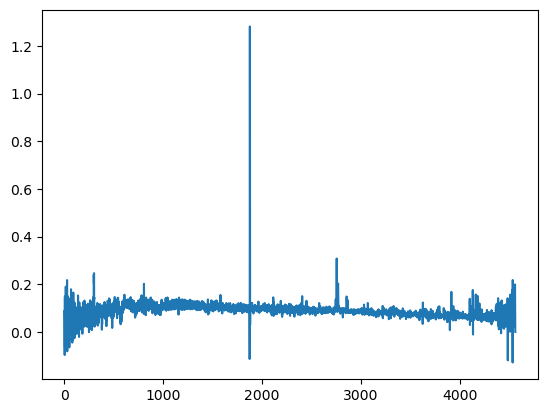

In [13]:
#read spectral data
plt.figure()
spectra=flux[:,40,50]
plt.plot(spectra)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import os
from astropy.io import fits

# --- Load MaNGA hyperspectral FITS cube ---
cube_path = r"C:\Users\adity\Downloads\manga-7443-12703-LOGCUBE\manga-7443-12703-LOGCUBE.fits"
if not os.path.exists(cube_path):
    raise FileNotFoundError(f"File not found: {cube_path}")

with fits.open(cube_path) as hdul:
    flux_cube = hdul['FLUX'].data  # shape: (bands, height, width)

# Reorder to (height, width, bands)
flux_cube = np.moveaxis(flux_cube, 0, -1)  # shape: (H, W, B)
H, W, B = flux_cube.shape
print(f"Loaded cube with shape: ({H}, {W}, {B})")

# --- Flatten & scale ---
pixels = flux_cube.reshape(-1, B)
scaler = StandardScaler()
pixels_scaled = scaler.fit_transform(pixels)

# --- PCA for dimensionality reduction ---
pca = PCA(n_components=4)
latent_features = pca.fit_transform(pixels_scaled)

# --- Clustering with KMeans ---
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(latent_features)

# --- Save models and cluster map ---
joblib.dump(scaler, "pca_scaler.pkl")
joblib.dump(pca, "pca_model.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")
np.save("cluster_map.npy", cluster_labels.reshape(H, W))
print("Model trained and saved!")

# --- Predict metallicity class at a pixel ---
while True:
    try:
        x = int(input(f"\nEnter X coordinate (0 to {W - 1}): "))
        y = int(input(f"Enter Y coordinate (0 to {H - 1}): "))
        if x < 0 or x >= W or y < 0 or y >= H:
            print("Invalid coordinates. Try again.")
            continue

        # Reload models
        scaler = joblib.load("pca_scaler.pkl")
        pca = joblib.load("pca_model.pkl")
        kmeans = joblib.load("kmeans_model.pkl")

        # Predict class
        spectrum = flux_cube[y, x, :]
        spectrum_scaled = scaler.transform(spectrum.reshape(1, -1))
        latent = pca.transform(spectrum_scaled)
        cluster = kmeans.predict(latent)[0]

        label = "Galaxy" if cluster == 0 else "Star"
        print(f"At pixel ({x},{y}), predicted class: {label} (Cluster {cluster})")

    except KeyboardInterrupt:
        print("\nExiting.")
        break


Loaded cube with shape: (74, 74, 4563)
Model trained and saved!
